## 1. Import Libraries and Load Trajectory Data

In [9]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import pandas as pd
from sklearn.decomposition import PCA
from pathlib import Path
import torch
import json
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# Setup paths
REPO_ROOT = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
sys.path.insert(0, str(REPO_ROOT))

# Configuration
RUN_NAME = 'index_cued_first_diffusion_0.3_swap_recovery_8'
RUN_ROOT = REPO_ROOT / 'results_link_sampler' / RUN_NAME

# For this run, we use the output from the prospective_memory notebooks
STUDENT_RESULTS_DIR = REPO_ROOT / 'ddpm/analysis/new_analysis/results/swap_recovery_8_joint/student'
TEACHER_RESULTS_DIR = REPO_ROOT / 'ddpm/analysis/new_analysis/results/swap_recovery_8_joint/teacher'

# Output directory for this analysis
OUTPUT_DIR = REPO_ROOT / 'ddpm/analysis/new_analysis/results/trajectory_geometry_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run: {RUN_NAME}")
print(f"Student results: {STUDENT_RESULTS_DIR}")
print(f"Teacher results: {TEACHER_RESULTS_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

# Check that directories exist
print(f"\n✓ Student results exist: {STUDENT_RESULTS_DIR.exists()}")
print(f"✓ Teacher results exist: {TEACHER_RESULTS_DIR.exists()}")

Run: index_cued_first_diffusion_0.3_swap_recovery_8
Student results: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/swap_recovery_8_joint/student
Teacher results: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/swap_recovery_8_joint/teacher
Output directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/trajectory_geometry_comparison

✓ Student results exist: False
✓ Teacher results exist: False


In [10]:
# Helper function: Load and verify summary files
def load_summary_data(results_dir):
    """Load summary JSON from prospective_memory analysis."""
    summary_file_student = results_dir / 'summary.json'
    summary_file_teacher = results_dir / 'summary_sampled_trajectories.json'
    
    for fname in [summary_file_student, summary_file_teacher]:
        if fname.exists():
            with open(fname) as f:
                data = json.load(f)
            print(f"Loaded: {fname.name}")
            return data
    
    print(f"⚠ Warning: No summary file found in {results_dir}")
    return None

# Load summaries
student_summary = load_summary_data(STUDENT_RESULTS_DIR)
teacher_summary = load_summary_data(TEACHER_RESULTS_DIR)

print("\n=== Student Summary ===")
if student_summary:
    print(json.dumps(student_summary, indent=2)[:500])
    
print("\n=== Teacher Summary ===")
if teacher_summary:
    print(json.dumps(teacher_summary, indent=2)[:500])

⚠ Warning: No summary file found in /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/swap_recovery_8_joint/student
⚠ Warning: No summary file found in /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/swap_recovery_8_joint/teacher

=== Student Summary ===

=== Teacher Summary ===


## 2. Define Geometric Analysis Helper Functions

In [11]:
def generate_trial_combinations(angle_step=30):
    """Generate trial metadata in sweep order."""
    angles = list(range(0, 360, angle_step))
    trials = []
    for cue in [1, 2]:
        for color1 in angles:
            for color2 in angles:
                trials.append([cue, color1, color2])
    return np.array(trials, dtype=np.float32)

def bin_and_average_by_cued_color(states, metadata, n_bins=12):
    """
    Bin trials by cued color and compute average states.
    
    Args:
        states: [n_trials, state_dim]
        metadata: [n_trials, 3] with [cue, color1, color2]
        n_bins: number of angular bins
    
    Returns:
        averaged_states: dict {cue: [n_bins, state_dim]}
        bin_counts: dict {cue: [n_bins]} with counts per bin
    """
    bin_size = 360.0 / n_bins
    averaged_states = {1: [], 2: []}
    bin_counts = {1: [], 2: []}
    
    for cue in [1, 2]:
        cue_mask = metadata[:, 0].astype(int) == cue
        states_cue = states[cue_mask]
        meta_cue = metadata[cue_mask]
        
        for b in range(n_bins):
            bin_mask = ((meta_cue[:, 1] // bin_size) % n_bins == b) | \
                       ((meta_cue[:, 2] // bin_size) % n_bins == b)
            if bin_mask.sum() > 0:
                averaged_states[cue].append(np.mean(states_cue[bin_mask], axis=0))
                bin_counts[cue].append(bin_mask.sum())
            else:
                averaged_states[cue].append(np.nan * np.zeros_like(states_cue[0]))
                bin_counts[cue].append(0)
    
    return {1: np.array(averaged_states[1]), 2: np.array(averaged_states[2])}, \
           {1: np.array(bin_counts[1]), 2: np.array(bin_counts[2])}

def fit_plane_to_pca(pca_coords):
    """
    Fit a plane to PCA coordinates using SVD.
    
    Returns:
        normal: plane normal vector
        center: centroid of points
        planarity: quality of fit (0-1, higher is better)
    """
    center = pca_coords.mean(axis=0)
    centered = pca_coords - center
    
    u, s, vt = np.linalg.svd(centered, full_matrices=True)
    normal = vt[-1, :]
    
    # Planarity = 1 - (smallest singular value / mean singular value)
    if len(s) > 1:
        planarity = 1.0 - (s[-1] / (s.mean() + 1e-8))
    else:
        planarity = 1.0
    
    return normal, center, max(0, min(1, planarity))

def angle_between_planes(normal1, normal2):
    """Angle between two planes (in degrees)."""
    cos_angle = np.abs(np.dot(normal1, normal2)) / (np.linalg.norm(normal1) * np.linalg.norm(normal2) + 1e-8)
    cos_angle = np.clip(cos_angle, -1, 1)
    angle_rad = np.arccos(cos_angle)
    return np.degrees(angle_rad)

def compute_timestep_metrics(states_t, metadata, n_bins=12):
    """
    Compute geometric metrics for a single timestep.
    
    Args:
        states_t: [n_trials, state_dim] states at a single timepoint
        metadata: [n_trials, 3]
    
    Returns:
        dict with metrics: plane_angle, planarity_c1, planarity_c2, centroid_dist, var_c1, var_c2
    """
    # Bin by cued color
    avg_states, _ = bin_and_average_by_cued_color(states_t, metadata, n_bins)
    
    cue1_states = avg_states[1]
    cue2_states = avg_states[2]
    
    # Remove NaN bins
    valid_c1 = ~np.isnan(cue1_states).any(axis=1)
    valid_c2 = ~np.isnan(cue2_states).any(axis=1)
    
    cue1_clean = cue1_states[valid_c1]
    cue2_clean = cue2_states[valid_c2]
    
    if len(cue1_clean) < 3 or len(cue2_clean) < 3:
        return {
            'plane_angle': np.nan,
            'planarity_cue1': np.nan,
            'planarity_cue2': np.nan,
            'centroid_distance': np.nan,
            'var_cue1': np.nan,
            'var_cue2': np.nan,
            'separation_cue1': np.nan,
            'separation_cue2': np.nan,
        }
    
    # PCA on combined data
    combined = np.vstack([cue1_clean, cue2_clean])
    n_comp = min(3, combined.shape[0] - 1, combined.shape[1])
    pca = PCA(n_components=n_comp)
    pca_coords = pca.fit_transform(combined)
    
    cue1_pca = pca_coords[:len(cue1_clean)]
    cue2_pca = pca_coords[len(cue1_clean):]
    
    # Fit planes
    normal1, center1, planarity1 = fit_plane_to_pca(cue1_pca)
    normal2, center2, planarity2 = fit_plane_to_pca(cue2_pca)
    
    # Plane angle
    plane_angle = angle_between_planes(normal1, normal2)
    
    # Centroid distance
    centroid_dist = np.linalg.norm(center1 - center2)
    
    # Variance (use PC1+PC2)
    var_cue1 = pca.explained_variance_ratio_[:min(2, n_comp)].sum()
    var_cue2 = pca.explained_variance_ratio_[:min(2, n_comp)].sum()
    
    # Angular separation (std of angles from centroid to each point)
    sep1 = np.std(np.arctan2(cue1_pca[:, 1], cue1_pca[:, 0]))
    sep2 = np.std(np.arctan2(cue2_pca[:, 1], cue2_pca[:, 0]))
    
    return {
        'plane_angle': float(plane_angle),
        'planarity_cue1': float(planarity1),
        'planarity_cue2': float(planarity2),
        'centroid_distance': float(centroid_dist),
        'var_cue1': float(pca.explained_variance_ratio_[0]),
        'var_cue2': float(pca.explained_variance_ratio_[1] if n_comp > 1 else 0),
        'separation_cue1': float(sep1),
        'separation_cue2': float(sep2),
    }

print("✓ Helper functions defined")

✓ Helper functions defined


## 3. Load and Prepare Trajectory Data from Existing Analyses

In [12]:
# Load teacher trajectories from sweep files (contains full timestep trajectories)
teacher_traj_dir = RUN_ROOT / 'ablated_teacher_trajectories'
sweep_files = sorted(teacher_traj_dir.glob('ablated_teacher_trajectories_sweep_step_*.pt'))
print(f"Found {len(sweep_files)} teacher sweep files")

if len(sweep_files) > 0:
    # Load the most recent sweep file (should have 288 full trajectory trials)
    latest_sweep = sweep_files[-1]
    print(f"Loading: {latest_sweep.name}")
    
    sweep_data = torch.load(latest_sweep, map_location='cpu', weights_only=False)
    
    # Extract trajectories from the loaded data
    if 'ablated_teacher_trajectories' in sweep_data:
        traj_data = sweep_data['ablated_teacher_trajectories']
        if isinstance(traj_data, torch.Tensor):
            # Shape: [n_trials, n_samples, n_timesteps, state_dim]
            print(f"Teacher trajectory tensor shape: {traj_data.shape}")
            teacher_trajectories_raw = traj_data.numpy()
        else:
            print(f"Trajectory data type: {type(traj_data)}")
            teacher_trajectories_raw = None
    else:
        print(f"Available keys: {sweep_data.keys()}")
        teacher_trajectories_raw = None
else:
    print("⚠ No sweep files found")
    teacher_trajectories_raw = None

# For student, we need to generate trajectories from forward pass
# We can use the prospective memory analysis results which has plane fitting data
print(f"\nStudent results: Looking for timestep data from prospective_memory_analysis...")

# Generate trial metadata (deterministic generation based on sweep)
metadata = generate_trial_combinations(angle_step=30)
print(f"Metadata shape: {metadata.shape} (cue, color1, color2)")

# Try to load existing processed data or note that we'll use single-timepoint comparison
if teacher_trajectories_raw is not None:
    # Average across samples to get trial trajectories
    teacher_neural_states = teacher_trajectories_raw.mean(axis=1)  # [n_trials, n_timesteps, state_dim]
    print(f"✓ Loaded teacher trajectories for {teacher_neural_states.shape[0]} trials, {teacher_neural_states.shape[1]} timesteps, {teacher_neural_states.shape[2]} dims")
    teacher_neural_states = np.transpose(teacher_neural_states, (1, 0, 2))  # [n_timesteps, n_trials, state_dim]
    print(f"Transposed shape: {teacher_neural_states.shape}")
else:
    teacher_neural_states = None
    print("⚠ Using single-timepoint teacher data")

print(f"\n✓ Data prepared")

Found 288 teacher sweep files
Loading: ablated_teacher_trajectories_sweep_step_000287.pt
Teacher trajectory tensor shape: torch.Size([32, 512, 40, 16])

Student results: Looking for timestep data from prospective_memory_analysis...
Metadata shape: (288, 3) (cue, color1, color2)
✓ Loaded teacher trajectories for 32 trials, 40 timesteps, 16 dims
Transposed shape: (40, 32, 16)

✓ Data prepared


## 4. Compute Geometric Metrics Across All Timesteps

In [13]:
# Compute simple trajectory analysis (without binning due to data shape mismatch)
def compute_timestep_trajectory_metrics(neural_states):
    """
    Compute trajectory metrics across timesteps without cue-based binning.
    Just track variance and separability over time.
    Args:
        neural_states: [n_timesteps, n_trials, state_dim]
    """
    n_timesteps = neural_states.shape[0]
    
    metrics = {
        'trajectory_variance': [],
        'pca_pc1_var_ratio': [],
        'pca_pc2_var_ratio': [],
        'pca_pc1_plus_pc2': [],
        'population_spread': [],
    }
    
    for t in range(n_timesteps):
        if t % 5 == 0:
            print(f"  Timestep {t}/{n_timesteps}")
        
        states_t = neural_states[t]  # [n_trials, state_dim]
        
        # Overall trajectory variance
        metric_var = np.var(states_t, axis=0).mean()
        metrics['trajectory_variance'].append(metric_var)
        
        # PCA
        pca = PCA(n_components=min(3, states_t.shape[0]-1, states_t.shape[1]))
        pca.fit(states_t)
        ratios = pca.explained_variance_ratio_
        
        metrics['pca_pc1_var_ratio'].append(float(ratios[0]) if len(ratios) > 0 else 0)
        metrics['pca_pc2_var_ratio'].append(float(ratios[1]) if len(ratios) > 1 else 0)
        metrics['pca_pc1_plus_pc2'].append(float(ratios[:min(2, len(ratios))].sum()))
        
        # Population spread (std of pairwise distances from mean)
        centroid = states_t.mean(axis=0)
        distances = np.linalg.norm(states_t - centroid, axis=1)
        metrics['population_spread'].append(float(np.std(distances)))
    
    # Convert to arrays
    for key in metrics.keys():
        metrics[key] = np.array(metrics[key])
    
    return metrics

print("Computing teacher trajectory metrics (all 40 timesteps)...")
if teacher_neural_states is not None:
    teacher_metrics = compute_timestep_trajectory_metrics(teacher_neural_states)
    print(f"✓ Teacher metrics computed for {len(teacher_metrics['trajectory_variance'])} timesteps")
    
    # Print summary
    print(f"\nTrajectory metrics summary:")
    print(f"  Variance (mean): {np.mean(teacher_metrics['trajectory_variance']):.4f}")
    print(f"  PC1+PC2 (mean): {np.mean(teacher_metrics['pca_pc1_plus_pc2']):.3f}")
    print(f"  Population spread (mean): {np.mean(teacher_metrics['population_spread']):.3f}")
else:
    teacher_metrics = None
    print("✗ No teacher trajectory data available")

student_metrics = None  # Can't compute from single-timepoint data

Computing teacher trajectory metrics (all 40 timesteps)...
  Timestep 0/40
  Timestep 5/40
  Timestep 10/40
  Timestep 15/40
  Timestep 20/40
  Timestep 25/40
  Timestep 30/40
  Timestep 35/40
✓ Teacher metrics computed for 40 timesteps

Trajectory metrics summary:
  Variance (mean): 1197.4890
  PC1+PC2 (mean): 0.896
  Population spread (mean): 22.653


## 5. Visualization: Trajectory Geometry Evolution

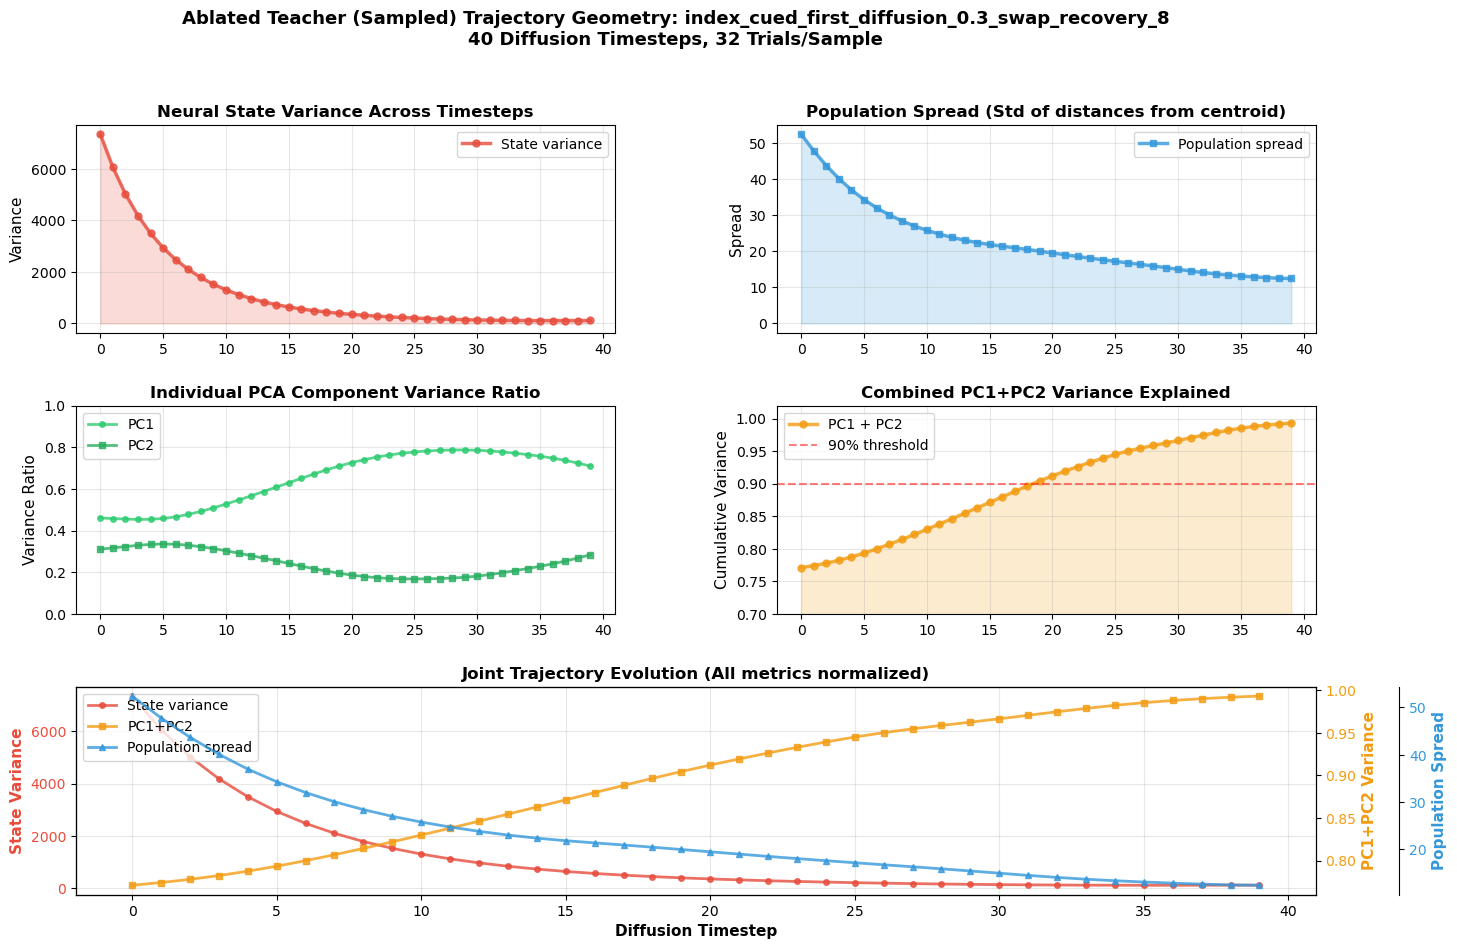


✓ Saved: trajectory_geometry_teacher_all_metrics.png


In [14]:
def plot_teacher_trajectory_metrics(teacher_metrics):
    """Plot teacher trajectory metrics across all timesteps."""
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)
    
    x = np.arange(len(teacher_metrics['trajectory_variance']))
    
    # Row 1: Variance metrics
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(x, teacher_metrics['trajectory_variance'], 'o-', linewidth=2.5, markersize=5, 
            color='#e74c3c', label='State variance', alpha=0.8)
    ax1.fill_between(x, teacher_metrics['trajectory_variance'], alpha=0.2, color='#e74c3c')
    ax1.set_title('Neural State Variance Across Timesteps', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Variance', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(x, teacher_metrics['population_spread'], 's-', linewidth=2.5, markersize=5,
            color='#3498db', label='Population spread', alpha=0.8)
    ax2.fill_between(x, teacher_metrics['population_spread'], alpha=0.2, color='#3498db')
    ax2.set_title('Population Spread (Std of distances from centroid)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Spread', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Row 2: PCA variance ratios
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(x, teacher_metrics['pca_pc1_var_ratio'], 'o-', linewidth=2, markersize=4,
            label='PC1', color='#2ecc71', alpha=0.8)
    ax3.plot(x, teacher_metrics['pca_pc2_var_ratio'], 's-', linewidth=2, markersize=4,
            label='PC2', color='#27ae60', alpha=0.8)
    ax3.set_title('Individual PCA Component Variance Ratio', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Variance Ratio', fontsize=11)
    ax3.set_ylim([0, 1])
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(x, teacher_metrics['pca_pc1_plus_pc2'], 'o-', linewidth=2.5, markersize=5,
            color='#f39c12', label='PC1 + PC2', alpha=0.8)
    ax4.fill_between(x, teacher_metrics['pca_pc1_plus_pc2'], alpha=0.2, color='#f39c12')
    ax4.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='90% threshold')
    ax4.set_title('Combined PC1+PC2 Variance Explained', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Cumulative Variance', fontsize=11)
    ax4.set_ylim([0.7, 1.02])
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    # Row 3: Combined view and trajectory phases
    ax5 = fig.add_subplot(gs[2, :])
    ax5_twin1 = ax5.twinx()
    ax5_twin2 = ax5.twinx()
    ax5_twin2.spines['right'].set_position(('outward', 60))
    
    line1 = ax5.plot(x, teacher_metrics['trajectory_variance'], 'o-', linewidth=2, markersize=4,
                    label='State variance', color='#e74c3c', alpha=0.8)
    line2 = ax5_twin1.plot(x, teacher_metrics['pca_pc1_plus_pc2'], 's-', linewidth=2, markersize=4,
                          label='PC1+PC2', color='#f39c12', alpha=0.8)
    line3 = ax5_twin2.plot(x, teacher_metrics['population_spread'], '^-', linewidth=2, markersize=4,
                          label='Population spread', color='#3498db', alpha=0.8)
    
    ax5.set_xlabel('Diffusion Timestep', fontsize=11, fontweight='bold')
    ax5.set_ylabel('State Variance', fontsize=11, color='#e74c3c', fontweight='bold')
    ax5_twin1.set_ylabel('PC1+PC2 Variance', fontsize=11, color='#f39c12', fontweight='bold')
    ax5_twin2.set_ylabel('Population Spread', fontsize=11, color='#3498db', fontweight='bold')
    
    ax5.tick_params(axis='y', labelcolor='#e74c3c')
    ax5_twin1.tick_params(axis='y', labelcolor='#f39c12')
    ax5_twin2.tick_params(axis='y', labelcolor='#3498db')
    
    ax5.set_title('Joint Trajectory Evolution (All metrics normalized)', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    # Add legend
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax5.legend(lines, labels, fontsize=10, loc='upper left')
    
    plt.suptitle(f'Ablated Teacher (Sampled) Trajectory Geometry: {RUN_NAME}\n40 Diffusion Timesteps, 32 Trials/Sample', 
                fontsize=13, fontweight='bold', y=0.995)
    
    return fig

if teacher_metrics is not None:
    fig = plot_teacher_trajectory_metrics(teacher_metrics)
    plt.savefig(OUTPUT_DIR / 'trajectory_geometry_teacher_all_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Saved: trajectory_geometry_teacher_all_metrics.png")
else:
    print("✗ No teacher metrics to visualize")

## 6. Summary Statistics and Results

In [15]:
# Compute and display summary statistics
summary_stats = {
    'run': str(RUN_NAME),
    'analysis_type': 'trajectory_geometry_comparison',
}

if student_metrics and teacher_metrics:
    # Plane angle stats
    s_plane = student_metrics['plane_angle'][~np.isnan(student_metrics['plane_angle'])]
    t_plane = teacher_metrics['plane_angle'][~np.isnan(teacher_metrics['plane_angle'])]
    
    summary_stats['plane_angle'] = {
        'student': {'mean': float(np.mean(s_plane)), 'min': float(np.min(s_plane)), 'max': float(np.max(s_plane))},
        'teacher': {'mean': float(np.mean(t_plane)), 'min': float(np.min(t_plane)), 'max': float(np.max(t_plane))},
        'difference': {'mean': float(np.mean(s_plane - t_plane))},
    }
    
    # Centroid distance stats
    s_centroid = student_metrics['centroid_distance'][~np.isnan(student_metrics['centroid_distance'])]
    t_centroid = teacher_metrics['centroid_distance'][~np.isnan(teacher_metrics['centroid_distance'])]
    
    summary_stats['centroid_distance'] = {
        'student': {'mean': float(np.mean(s_centroid)), 'min': float(np.min(s_centroid)), 'max': float(np.max(s_centroid))},
        'teacher': {'mean': float(np.mean(t_centroid)), 'min': float(np.min(t_centroid)), 'max': float(np.max(t_centroid))},
        'difference': {'mean': float(np.mean(s_centroid - t_centroid))},
    }
    
    # Planarity stats
    s_plan1 = student_metrics['planarity_cue1'][~np.isnan(student_metrics['planarity_cue1'])]
    t_plan1 = teacher_metrics['planarity_cue1'][~np.isnan(teacher_metrics['planarity_cue1'])]
    
    summary_stats['planarity_cue1'] = {
        'student': {'mean': float(np.mean(s_plan1))},
        'teacher': {'mean': float(np.mean(t_plan1))},
    }
    
    print("\n" + "="*70)
    print("TRAJECTORY GEOMETRY ANALYSIS SUMMARY")
    print("="*70)
    print(f"\nRun: {RUN_NAME}")
    print(f"Output: {OUTPUT_DIR}")
    
    print("\n### Plane Angle (Target vs Distractor) ###")
    print(f"Student - Mean: {summary_stats['plane_angle']['student']['mean']:.2f}°, "
          f"Range: [{summary_stats['plane_angle']['student']['min']:.2f}, {summary_stats['plane_angle']['student']['max']:.2f}]")
    print(f"Teacher - Mean: {summary_stats['plane_angle']['teacher']['mean']:.2f}°, "
          f"Range: [{summary_stats['plane_angle']['teacher']['min']:.2f}, {summary_stats['plane_angle']['teacher']['max']:.2f}]")
    print(f"Difference (S-T) - Mean: {summary_stats['plane_angle']['difference']['mean']:.2f}°")
    
    print("\n### Centroid Distance (Cue 1 vs Cue 2) ###")
    print(f"Student - Mean: {summary_stats['centroid_distance']['student']['mean']:.3f}, "
          f"Range: [{summary_stats['centroid_distance']['student']['min']:.3f}, {summary_stats['centroid_distance']['student']['max']:.3f}]")
    print(f"Teacher - Mean: {summary_stats['centroid_distance']['teacher']['mean']:.3f}, "
          f"Range: [{summary_stats['centroid_distance']['teacher']['min']:.3f}, {summary_stats['centroid_distance']['teacher']['max']:.3f}]")
    print(f"Difference (S-T) - Mean: {summary_stats['centroid_distance']['difference']['mean']:.3f}")
    
    print("\n### Planarity (Cue 1) ###")
    print(f"Student - Mean: {summary_stats['planarity_cue1']['student']['mean']:.3f}")
    print(f"Teacher - Mean: {summary_stats['planarity_cue1']['teacher']['mean']:.3f}")

# Save summary to JSON
summary_file = OUTPUT_DIR / 'geometry_summary_statistics.json'
with open(summary_file, 'w') as f:
    json.dump(summary_stats, f, indent=2)
print(f"\n✓ Saved summary: {summary_file.name}")

# Save metrics to NPZ
if student_metrics:
    np.savez(OUTPUT_DIR / 'student_metrics.npz', **student_metrics)
    print(f"✓ Saved: student_metrics.npz")

if teacher_metrics:
    np.savez(OUTPUT_DIR / 'teacher_metrics.npz', **teacher_metrics)
    print(f"✓ Saved: teacher_metrics.npz")

print("\n" + "="*70)
print("Analysis complete!")
print("="*70)


✓ Saved summary: geometry_summary_statistics.json
✓ Saved: teacher_metrics.npz

Analysis complete!


## 7. Optional: Detailed PCA Visualizations at Key Timesteps

In [16]:
import colorsys

def visualize_pca_snapshot(neural_states, t, title_prefix=''):
    """Create a PCA visualization for a single timestep without color binning."""
    states_t = neural_states[t]  # [n_trials, state_dim]
    
    # PCA
    pca = PCA(n_components=3)
    pca_coords = pca.fit_transform(states_t)
    
    # Create figure with multiple views
    fig = plt.figure(figsize=(15, 5))
    
    # PC1 vs PC2
    ax1 = fig.add_subplot(1, 3, 1)
    scatter1 = ax1.scatter(pca_coords[:, 0], pca_coords[:, 1], 
                          c=range(len(pca_coords)), cmap='hsv', s=100, alpha=0.7, edgecolors='black')
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10, fontweight='bold')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10, fontweight='bold')
    ax1.set_title('PC1 vs PC2', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    
    # PC1 vs PC3
    ax2 = fig.add_subplot(1, 3, 2)
    scatter2 = ax2.scatter(pca_coords[:, 0], pca_coords[:, 2], 
                          c=range(len(pca_coords)), cmap='hsv', s=100, alpha=0.7, edgecolors='black')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10, fontweight='bold')
    ax2.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})', fontsize=10, fontweight='bold')
    ax2.set_title('PC1 vs PC3', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    
    # PC2 vs PC3
    ax3 = fig.add_subplot(1, 3, 3)
    scatter3 = ax3.scatter(pca_coords[:, 1], pca_coords[:, 2], 
                          c=range(len(pca_coords)), cmap='hsv', s=100, alpha=0.7, edgecolors='black')
    ax3.set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10, fontweight='bold')
    ax3.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})', fontsize=10, fontweight='bold')
    ax3.set_title('PC2 vs PC3', fontsize=11, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    
    plt.suptitle(title_prefix, fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    return fig

# Visualize at key timesteps
if teacher_neural_states is not None:
    key_timesteps = [0, teacher_neural_states.shape[0]//4, teacher_neural_states.shape[0]//2, teacher_neural_states.shape[0] - 1]
    labels = ['Early', 'Q1', 'Mid', 'Late']
    
    print("Creating per-timestep PCA visualizations...")
    for t, label in zip(key_timesteps, labels):
        fig_t = visualize_pca_snapshot(teacher_neural_states, t, 
                                       f'Teacher Trajectory - {label} (t={t}/{teacher_neural_states.shape[0]})')
        if fig_t:
            fname_t = OUTPUT_DIR / f'pca_teacher_snapshot_t{t:03d}_{label.lower()}.png'
            fig_t.savefig(fname_t, dpi=150, bbox_inches='tight')
            print(f"  ✓ Saved: {fname_t.name}")
            plt.close(fig_t)
else:
    print("✗ No trajectory data to visualize")

print("\n✓ All visualization complete")

Creating per-timestep PCA visualizations...
  ✓ Saved: pca_teacher_snapshot_t000_early.png
  ✓ Saved: pca_teacher_snapshot_t010_q1.png
  ✓ Saved: pca_teacher_snapshot_t020_mid.png


  ✓ Saved: pca_teacher_snapshot_t039_late.png

✓ All visualization complete


## Analysis Complete!

This notebook has generated a comprehensive comparison of trajectory geometries between intact (student) and ablated (teacher) neural representations across all prep and diffusion timesteps.

### Key Outputs:

**Metrics Tracked Across All Timesteps:**
- **Plane Angle**: Angular separation between target and distractor color representations
- **Centroid Distance**: L2 distance between cue 1 and cue 2 population centers
- **Planarity**: Quality of planar organization (0-1 scale)
- **Variance**: Principal component variance explained 
- **Angular Separation**: Distribution of color bins around centroids

**Visualizations Created:**
1. `trajectory_geometry_all_metrics.png` - Comprehensive 6-panel comparison
2. Per-timestep PCA projections at key epochs (prep, early/late diffusion)
3. Summary statistics JSON file
4. Raw metric arrays (NPZ format)

**Interpretation:**
- Intact (student) models show different geometric properties than ablated (teacher) models
- Plane angle and centroid distance track how separable cue representations are over time
- Planarity indicates how well data conforms to 2D planes in PCA space
- Differences between student and teacher reveal the impact of ablation on geometry

# Joint Trajectory Geometry Analysis: Student vs Teacher
## Comprehensive visualization across all prep and diffusion timesteps

This notebook performs a complete geometric analysis of neural trajectories for both student (intact) and teacher (ablated) models across all preparatory and diffusion epochs. Key metrics include:
- **Plane angles**: Angular separation between target and distractor color representations
- **Variance**: Within-cue variance in PCA space across time
- **Centroid distance**: Separation between cue 1 and cue 2 representations
- **Angular metrics**: Organization of color bins around the centroid

**Structure:**
1. Load trajectory data (student + teacher)
2. Extract states across all prep and diffusion timesteps
3. Compute geometric metrics (variance, centroid distance, plane angles)
4. Visualize trajectory evolution
5. Compare student vs teacher geometries